In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
import requests
from rdflib import Graph, URIRef, Literal, Namespace
import io
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from plotly_resampler import FigureResampler
import plotly.graph_objects as go

In [ ]:
#VIRTUOSO_URL = "http://localhost:8890/sparql-graph-crud"
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI = "http://example.com/Gent-Terneuzen"
USERNAME = "dba"
PASSWORD = "dba"
AUTH  = (USERNAME,PASSWORD)

In [ ]:
params = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors

In [ ]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT  DISTINCT ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data = res.json()
bindings = data['results']['bindings']

for row in bindings:
    # Extract the URI string and add it to the set
    sensor_uri = row['sensor']['value']
    sensor_set.add(sensor_uri)

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)


Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289441042'}


# Reframe the data 

In [ ]:


# 1. Initialize an empty DataFrame for the master table
# We will start with just the 'time' column or an empty DF
final_df = pd.DataFrame()

print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    # Use the sensor URI (or just the ID part) as the column name
    column_name = sensor_uri.split('/')[-1] 
    
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{ 
            GRAPH <{GRAPH_URI}> {{ 
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }} 
        }} 
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        
        # 2. Create a temporary DF for THIS sensor
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']), 'unixtime': int(row['unixtime']['value'])} 
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            
            # 3. Merge this sensor into the final_df
            if final_df.empty:
                final_df = temp_df
            else:
                # 'outer' join ensures we keep timestamps even if some sensors are missing data
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')

            
            print(f"Added column for sensor: {column_name}")

# 4. Final touches
final_df = final_df.sort_values('time').set_index('time')

print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289435042
Added column for sensor: 289423042
Added column for sensor: 289429042
Added column for sensor: 289441042
Finished!
                           289435042    unixtime  289423042  289429042  \
time                                                                     
2021-03-03 23:15:00+00:00    3606.54  1614813300        NaN    1605.77   
2021-03-03 23:30:00+00:00        NaN  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    3556.45  1614815100     902.27    1602.34   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN    1611.26   
2021-03-04 00:15:00+00:00        NaN  1614816900     901.96    1614.24   

                           289441042  
time                                  
2021-03-03 23:15:00+00:00    4797.72  
2021-03-03 23:30:00+00:00    4717.80  
2021-03-03 23:45:00+00:00    4745.36  
2021-03-04 00:00:00+00:00        NaN  
2021-03-04 00:15:00+00:00        NaN  


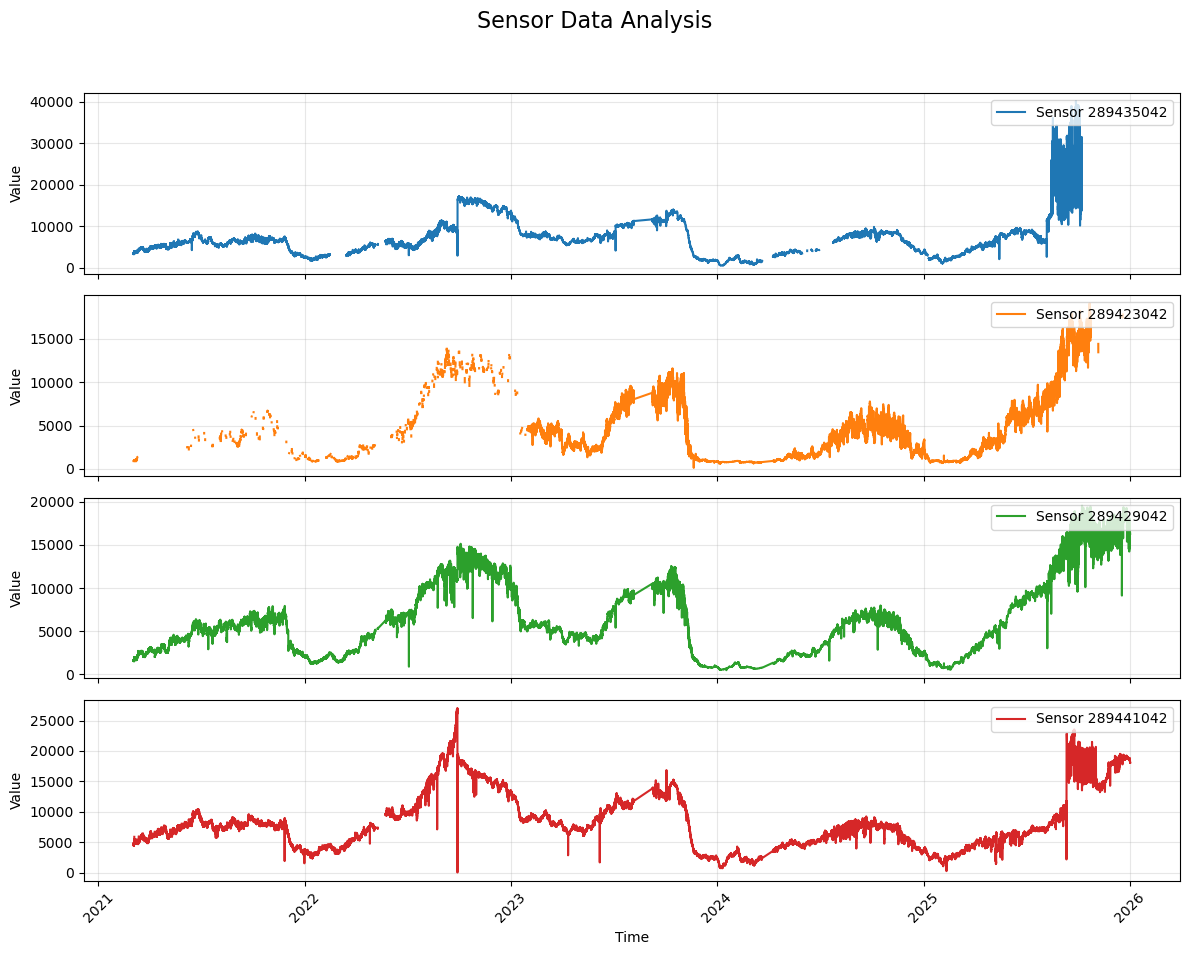

In [ ]:
# 1. Create a figure and a grid of 4 subplots (one for each sensor)
# sharex=True means zooming in on one x-axis zooms all of them
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 2. Iterate through sensors and plot on individual axes
for i, sensor in enumerate(sensors):
    ax = axes[i]
    
    # We use .index for time because it's your DataFrame index
    # Matplotlib handles NaNs by leaving gaps automatically
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# 3. Final formatting
plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for title

# 4. Show the plot
plt.show()

In [ ]:
df_clean = final_df.copy()
df_clean = df_clean.ffill().bfill()

feature_sensors = ['289435042', '289423042', '289429042', '289441042']
target_sensor   = '289441042'
target_col_idx  = feature_sensors.index(target_sensor)   # = 3
n_features      = len(feature_sensors)                   # = 4

data_arr = df_clean[feature_sensors].values               # (n_samples, 4)

# Split FIRST, then fit scaler on training data only
split_index  = int(len(data_arr) * 0.8)
train_data   = data_arr[:split_index]
test_data    = data_arr[split_index:]

scaler        = MinMaxScaler(feature_range=(0, 1))
train_scaled  = scaler.fit_transform(train_data)
test_scaled   = scaler.transform(test_data)

print(f"Train samples: {len(train_scaled):,}  |  Test samples: {len(test_scaled):,}")

Train samples: 128,646  |  Test samples: 32,162


In [56]:
time_steps = 672   # 1 week of 15-min readings
n_future   = 96    # 24 hours ahead

def create_sequences(dataset, time_steps, n_future, target_col):
    """Return X of shape (samples, time_steps, n_features)
       and y of shape (samples, n_future)."""
    X, y = [], []
    for i in range(len(dataset) - time_steps - n_future + 1):
        X.append(dataset[i : i + time_steps, :])                               # (time_steps, n_features)
        y.append(dataset[i + time_steps : i + time_steps + n_future, target_col])  # (n_future,)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, time_steps, n_future, target_col_idx)
X_test,  y_test  = create_sequences(test_scaled,  time_steps, n_future, target_col_idx)

print(f"X_train: {X_train.shape}  →  (samples, time_steps, n_features)")
print(f"y_train: {y_train.shape}  →  (samples, n_future)")

X_train: (127879, 672, 4)  →  (samples, time_steps, n_features)
y_train: (127879, 96)  →  (samples, n_future)


In [57]:
def build_lstm_autoencoder(time_steps, n_features, bottleneck=32,
                           dropout_rate=0.1, l2_reg=1e-4, noise_std=0.05):
    reg = regularizers.l2(l2_reg)

    # ── Encoder ──────────────────────────────────────────────────────────────
    enc_input = layers.Input(shape=(time_steps, n_features), name='enc_input')
    x = layers.GaussianNoise(noise_std)(enc_input)

    x = layers.LSTM(64, return_sequences=True,
                    kernel_regularizer=reg, name='lstm_enc_1')(x)
    x = layers.Dropout(dropout_rate)(x)

    z = layers.LSTM(bottleneck, return_sequences=False,
                    kernel_regularizer=reg, name='bottleneck')(x)  # (batch, bottleneck)

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = layers.RepeatVector(time_steps)(z)                          # (batch, time_steps, bottleneck)

    x = layers.LSTM(bottleneck, return_sequences=True,
                    kernel_regularizer=reg, name='lstm_dec_1')(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.LSTM(64, return_sequences=True,
                    kernel_regularizer=reg, name='lstm_dec_2')(x)

    dec_output = layers.TimeDistributed(
        layers.Dense(n_features, activation='sigmoid'), name='reconstruction'
    )(x)                                                            # (batch, time_steps, n_features)

    autoencoder = Model(enc_input, dec_output, name='lstm_autoencoder')
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse'
    )
    return autoencoder


autoencoder = build_lstm_autoencoder(
    time_steps=time_steps,
    n_features=n_features,
    bottleneck=32
)
autoencoder.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_input (InputLayer)          │ (None, 672, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_4                │ (None, 672, 4)         │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_1 (LSTM)               │ (None, 672, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 672, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (LSTM)               │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 672, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_1 (LSTM)               │ (None, 672, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 672, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_2 (LSTM)               │ (None, 672, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 672, 4)         │           260 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,492 (248.02 KB)

 Trainable params: 63,492 (248.02 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
full_scaled   = np.concatenate([train_scaled, test_scaled], axis=0)
last_sequence = full_scaled[-time_steps:].flatten()          # (20,)
last_sequence = np.reshape(last_sequence, (1, input_dim))    # (1, 20)

scaled_forecast = forecaster.predict(last_sequence)          # (1, 10)

dummy = np.zeros((n_future, len(feature_sensors)))
dummy[:, target_col_idx] = scaled_forecast[0]
forecast_real = scaler.inverse_transform(dummy)[:, target_col_idx]

print(f"Forecast for the next {n_future} steps (sensor {target_sensor}):")
for i, val in enumerate(forecast_real, 1):
    print(f"  t+{i:2d}: {val:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Forecast for the next 96 steps (sensor 289441042):
  t+ 1: 33968.28
  t+ 2: 33951.63
  t+ 3: 34031.50
  t+ 4: 33983.44
  t+ 5: 34046.13
  t+ 6: 34067.55
  t+ 7: 34029.55
  t+ 8: 34055.90
  t+ 9: 34020.61
  t+10: 34051.56
  t+11: 34067.86
  t+12: 34064.28
  t+13: 34098.42
  t+14: 34112.49
  t+15: 34114.58
  t+16: 34020.78
  t+17: 34069.24
  t+18: 34114.41
  t+19: 34115.13
  t+20: 34108.86
  t+21: 34165.15
  t+22: 34144.27
  t+23: 34154.86
  t+24: 34129.87
  t+25: 34155.75
  t+26: 34113.96
  t+27: 34134.00
  t+28: 34179.60
  t+29: 34170.03
  t+30: 34205.26
  t+31: 34234.89
  t+32: 34156.50
  t+33: 34140.93
  t+34: 34130.10
  t+35: 34138.27
  t+36: 34149.05
  t+37: 34173.00
  t+38: 34181.65
  t+39: 34182.49
  t+40: 34149.92
  t+41: 34123.70
  t+42: 34130.62
  t+43: 34166.71
  t+44: 34184.46
  t+45: 34239.74
  t+46: 34169.37
  t+47: 34118.62
  t+48: 33700.71
  t+49: 33717.71
  t+50: 33863.99
  t+51: 34070.07
  t+52: 33979.14
  t+53: 33958.24
  t+54: 34

In [53]:
test_preds_scaled = forecaster.predict(X_test)  # shape: (samples, 10)

print(f"{'Step':<8} {'MAE':>8} {'RMSE':>8}")
print("-" * 26)

for step in range(n_future):
    # Inverse-transform predictions
    dummy_p = np.zeros((len(test_preds_scaled), len(feature_sensors)))
    dummy_p[:, target_col_idx] = test_preds_scaled[:, step]
    preds_real = scaler.inverse_transform(dummy_p)[:, target_col_idx]

    # Inverse-transform actuals
    dummy_t = np.zeros((len(y_test), len(feature_sensors)))
    dummy_t[:, target_col_idx] = y_test[:, step]
    true_real = scaler.inverse_transform(dummy_t)[:, target_col_idx]

    mae  = mean_absolute_error(true_real, preds_real)
    rmse = np.sqrt(mean_squared_error(true_real, preds_real))
    print(f"  t+{step+1:<4}  {mae:>7.2f}  {rmse:>7.2f}")

982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Step          MAE     RMSE
--------------------------
  t+1     3006.69  3518.90
  t+2     3007.31  3519.79
  t+3     3018.65  3532.24
  t+4     3007.31  3519.97
  t+5     3020.45  3534.70
  t+6     3016.71  3530.73
  t+7     3002.36  3515.15
  t+8     2996.95  3509.35
  t+9     3005.14  3518.28
  t+10    3010.13  3523.91
  t+11    2993.12  3505.27
  t+12    3005.56  3519.19
  t+13    3008.63  3523.00
  t+14    3000.84  3514.95
  t+15    3011.41  3526.81
  t+16    3014.58  3530.71
  t+17    2997.28  3512.01
  t+18    2994.63  3509.16
  t+19    2996.90  3511.87
  t+20    3007.78  3524.11
  t+21    2998.27  3513.79
  t+22    2991.32  3506.28
  t+23    2999.10  3514.84
  t+24    2983.22  3497.49
  t+25    2984.19  3498.31
  t+26    2983.65  3497.92
  t+27    2993.58  3509.03
  t+28    2983.65  3498.17
  t+29    2992.88  3508.32
  t+30    2982.85  3497.42
  t+31    2981.65  3496.21
  t+32    2986.13  3501.29
  t+33    2975.46  3489.81
  t+34    2978

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


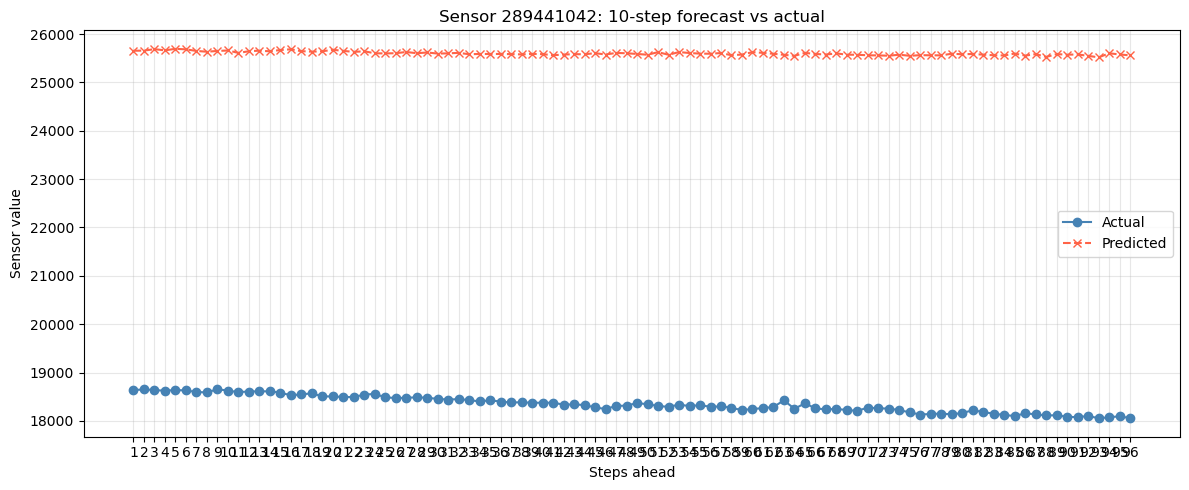

In [54]:
# Pick the last window in the test set and show its 10-step forecast
last_pred_scaled = forecaster.predict(X_test[-1:])  # shape: (1, 10)

dummy_p = np.zeros((n_future, len(feature_sensors)))
dummy_p[:, target_col_idx] = last_pred_scaled[0]
pred_real = scaler.inverse_transform(dummy_p)[:, target_col_idx]

dummy_t = np.zeros((n_future, len(feature_sensors)))
dummy_t[:, target_col_idx] = y_test[-1]
true_real = scaler.inverse_transform(dummy_t)[:, target_col_idx]

steps = range(1, n_future + 1)
plt.figure(figsize=(12, 5))
plt.plot(steps, true_real,  label='Actual',    color='steelblue', marker='o')
plt.plot(steps, pred_real,  label='Predicted', color='tomato',    marker='x', linestyle='--')
plt.title(f'Sensor {target_sensor}: 10-step forecast vs actual')
plt.xlabel('Steps ahead')
plt.ylabel('Sensor value')
plt.xticks(steps)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()